In [53]:
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd

# Load Iris dataset
data = pd.read_csv("iris_data.csv")
X = data.iloc[:, [0, 3]].values  # Selecting column 0 and 3 from the Iris dataset for X
y = data.iloc[:, 4].values      # Selecting column 4 from the Iris dataset for y

In [60]:
def scaling(X):
    min_vals = np.min(X, axis=0)
    max_vals = np.max(X, axis=0)
    scaled_X = (X - min_vals) / (max_vals - min_vals)
    return scaled_X

X = scaling(X)

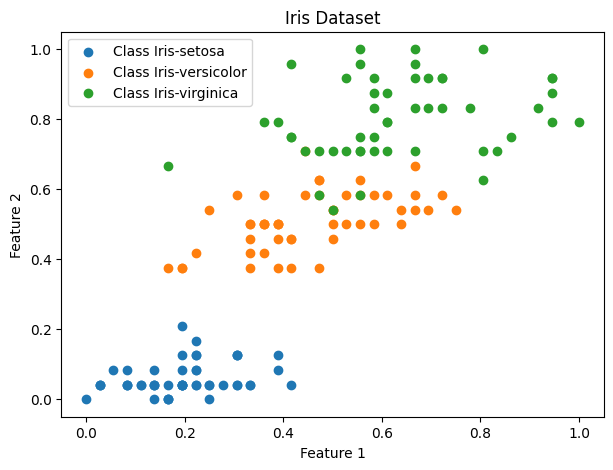

In [61]:
# Plotting
plt.figure(figsize=(7, 5))

# Plot each class separately
for class_label in np.unique(y):
    plt.scatter(X[y == class_label, 0], X[y == class_label, 1], label=f'Class {class_label}')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title('Iris Dataset')
plt.legend()
plt.show()
y0 = (y == 'Iris-setosa').astype(int)
y1 = (y == 'Iris-versicolor').astype(int)
y2 = (y == 'Iris-virginica').astype(int)

In [62]:

def step_func(z):
        return 1.0 if (z > 0) else 0.0

def perceptron(X, y, lr, epochs):
    m, n = X.shape

    theta = np.zeros((n+1,1))
    n_miss_list = []
    
    # Training.
    for epoch in range(epochs):
        
        n_miss = 0
        
        for idx, x_i in enumerate(X):
            
            # Insering 1 for bias, X0 = 1. en position 0
            x_i = np.insert(x_i, 0, 1).reshape(-1,1)
            
            # Calculating prediction/hypothesis.
            y_hat = step_func(np.dot(x_i.T, theta))
            # Updating if the example is misclassified.
            if (y_hat - y[idx]) != 0:
                theta += lr*((y[idx] - y_hat)*x_i)
                
                # Incrementing by 1.
                n_miss += 1
        
        # Appending number of misclassified examples
        # at every iteration.
        n_miss_list.append(n_miss)
        
    return theta, n_miss_list


In [63]:

def plot_decision_boundary(X, theta):
    x1 = [min(X[:, 0]), max(X[:, 0])]
    m = -theta[1] / theta[2]
    c = -theta[0] / theta[2]
    x2 = m * x1 + c
    
    # Plotting
    plt.plot(x1, x2, 'y-')

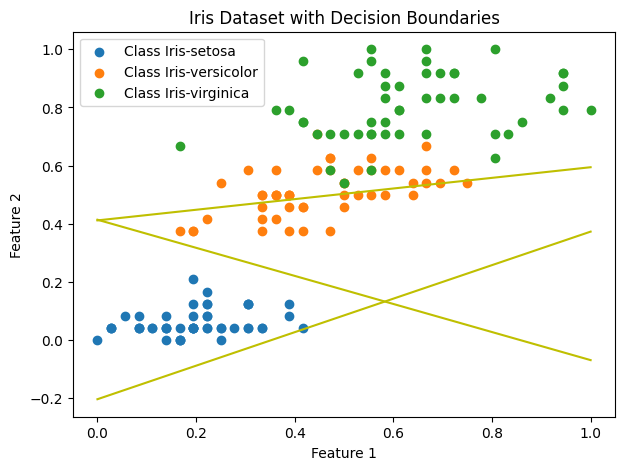

In [64]:
# Train perceptron for each class
theta0, miss_l0 = perceptron(X, y0, 0.5, 100)
theta1, miss_l1 = perceptron(X, y1, 0.5, 100)
theta2, miss_l2 = perceptron(X, y2, 0.5, 100)

# Plot decision boundary for each class
plt.figure(figsize=(7, 5))

# Plot each class separately
for class_label in np.unique(y):
    plt.scatter(X[y == class_label, 0], X[y == class_label, 1], label=f'Class {class_label}')

# Plot decision boundary for each class
plot_decision_boundary(X, theta0)
plot_decision_boundary(X, theta1)
plot_decision_boundary(X, theta2)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title('Iris Dataset with Decision Boundaries')
plt.legend()
plt.show()